In [67]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [71]:
df.shape

(7043, 21)

In [72]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [73]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

change the total charges dtype from object to float

In [74]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" #TotalCharges lo blank/string values unte avi error ivvakunda NaN ga convert chestundi.
)

In [75]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [76]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [77]:
df["TotalCharges"].isnull().sum()

np.int64(0)

sepaating the cols into numerical and categorical

In [78]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [79]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [80]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df = df.drop("customerID", axis=1)

In [83]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

outliers detection

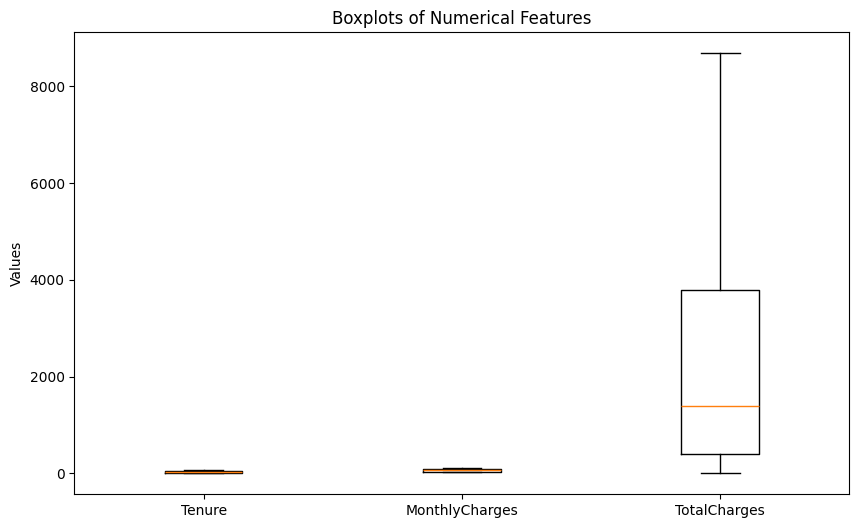

In [84]:
plt.figure(figsize=(10, 6))

plt.boxplot([
    df["tenure"],
    df["MonthlyCharges"],
    df["TotalCharges"]
])

plt.xticks(
    [1, 2, 3],
    ["Tenure", "MonthlyCharges", "TotalCharges"]
)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Values")

plt.show()

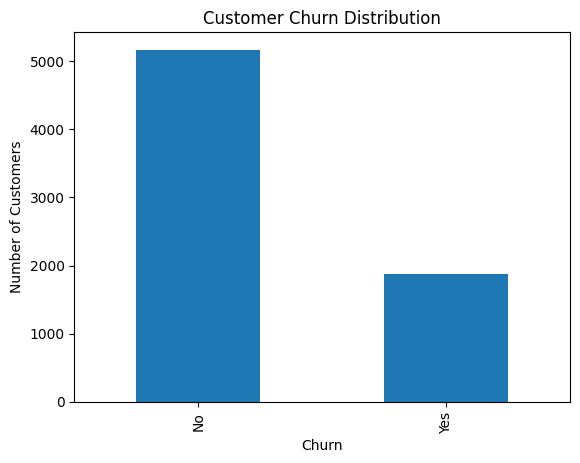

In [85]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [86]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


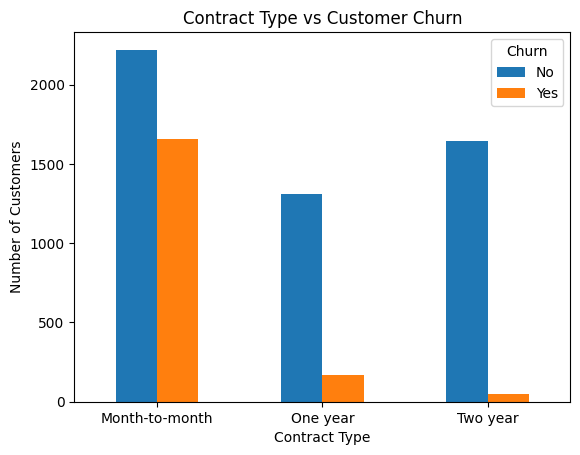

In [87]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(kind="bar")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)  # Horizontal
plt.legend(title="Churn")

plt.show()

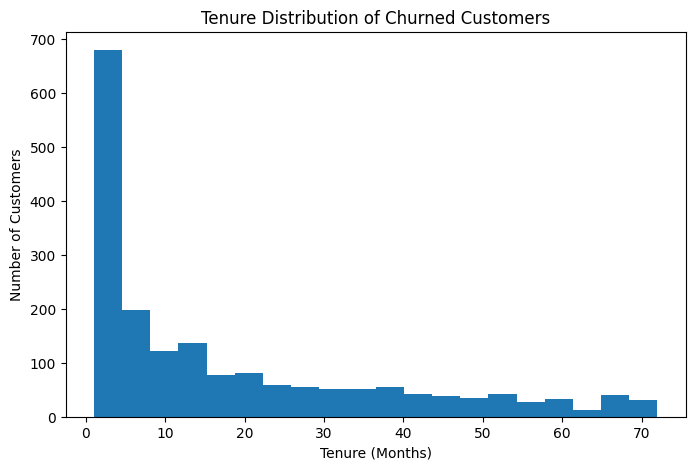

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == "Yes"]["tenure"],
    bins=20
)

plt.title("Tenure Distribution of Churned Customers")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

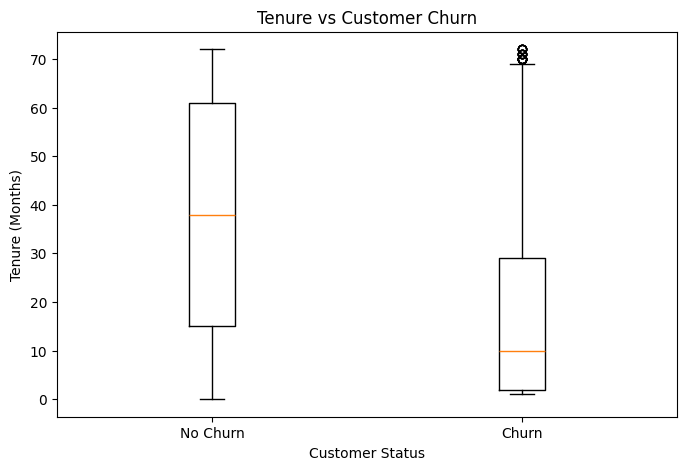

In [89]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Churn"] == "No"]["tenure"],
        df[df["Churn"] == "Yes"]["tenure"]
    ]
)

plt.xticks(
    [1, 2],
    ["No Churn", "Churn"]
)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")

plt.show()

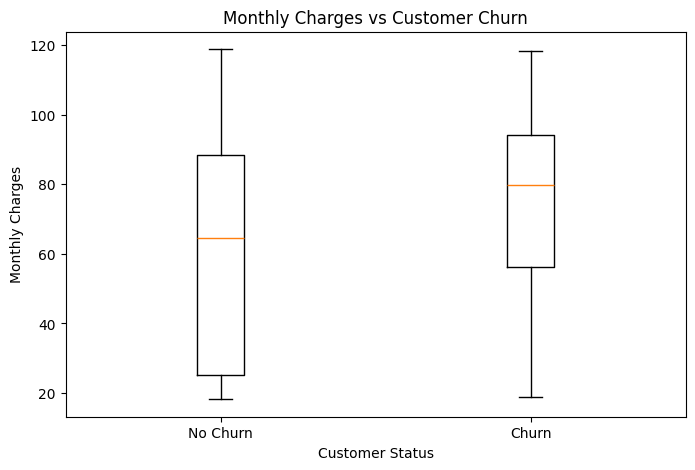

In [90]:
plt.figure(figsize=(8, 5))

plt.boxplot([
    df[df["Churn"] == "No"]["MonthlyCharges"],
    df[df["Churn"] == "Yes"]["MonthlyCharges"]
])

plt.xticks(
    [1, 2],
    ["No Churn", "Churn"]
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.show()

In [91]:
churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


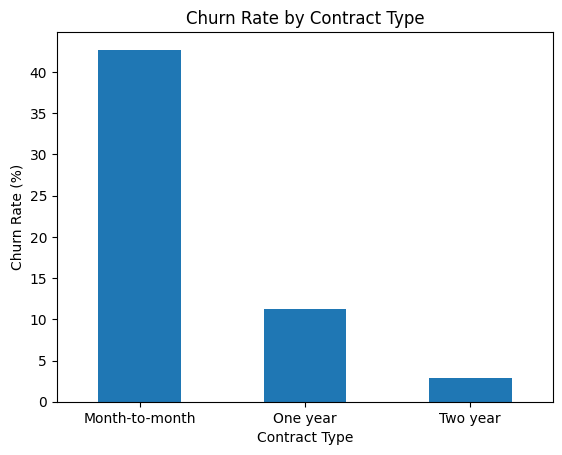

In [92]:
churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [93]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [94]:
churn_rate_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_rate_internet)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


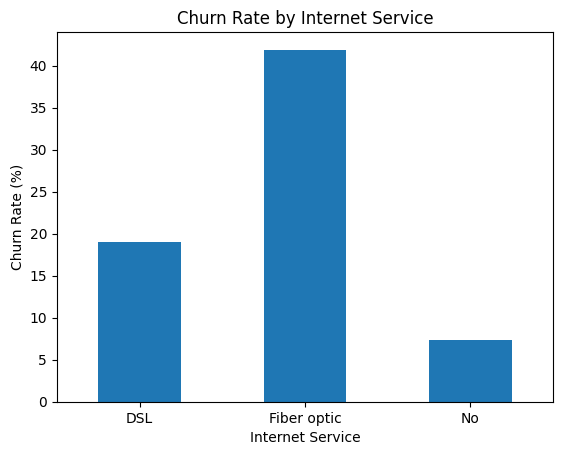

In [95]:
churn_rate_internet["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [96]:
churn_rate_payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_rate_payment)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


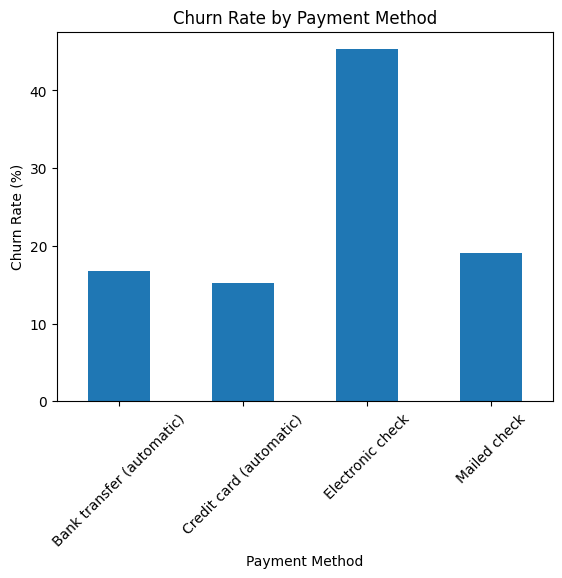

In [97]:
churn_rate_payment["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [98]:
churn_rate_support = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_rate_support)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


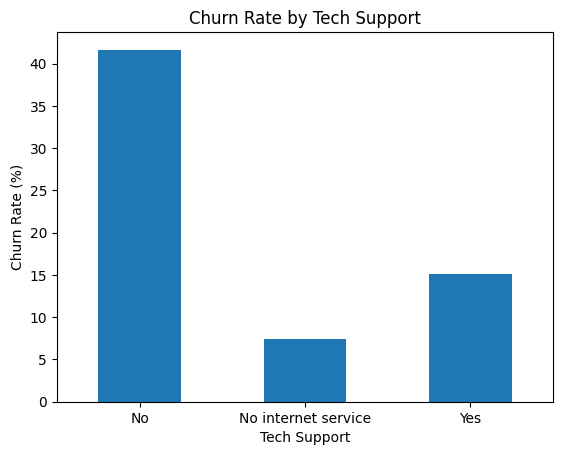

In [99]:
churn_rate_support["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [100]:
churn_rate_security = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_rate_security)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


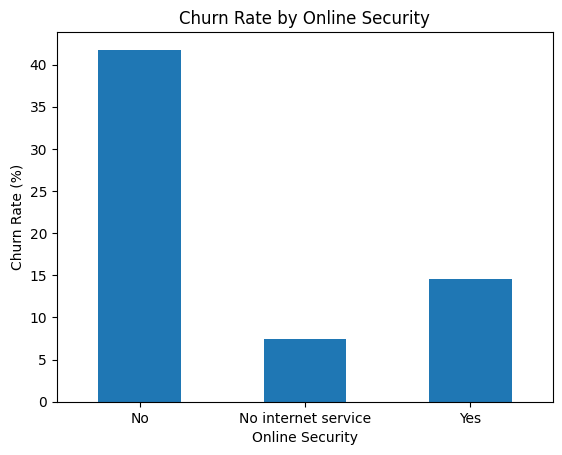

In [101]:
churn_rate_security["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Correlation matrix

In [102]:
corr = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].corr()

print(corr)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


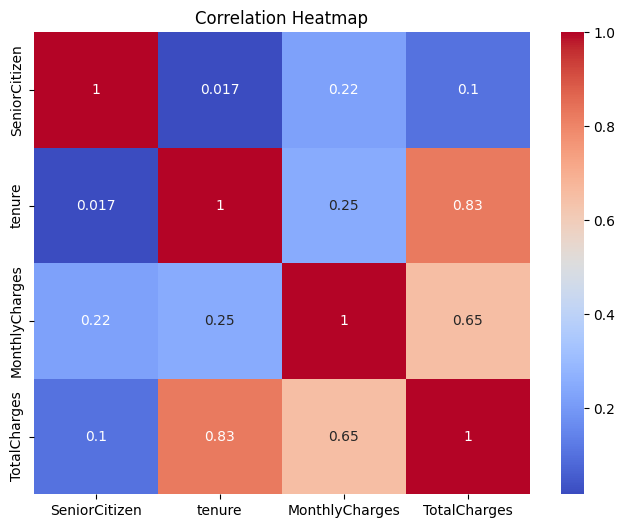

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [104]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [105]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


### Preparing Features (X) and Target (y)

Before splitting the data into training and testing sets, we need to separate the features (X) from the target variable (y). It's crucial that `X` still contains the original categorical columns so that our `ColumnTransformer` can correctly apply one-hot encoding as defined in the pipeline.

In [116]:
# Define features (X) by dropping the 'Churn' column from the dataframe
X = df.drop('Churn', axis=1)

# Define target variable (y) as the 'Churn' column
y = df['Churn']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (7043, 19)
Shape of y: (7043,)


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of X_train after re-split:", X_train.shape)
print("Shape of X_test after re-split:", X_test.shape)
print("Columns in X_train after re-split:", X_train.columns.tolist())

Shape of X_train after re-split: (5634, 19)
Shape of X_test after re-split: (1409, 19)
Columns in X_train after re-split: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [106]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [107]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [111]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [112]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [120]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [121]:
predictions = model.predict(X_test)

In [122]:
probabilities=model.predict_proba(  X_test)

In [123]:
churn_probabilities = model.predict_proba(X_test)[:, 1]

Evaluation Metrics

In [124]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [125]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[927 108]
 [165 209]]


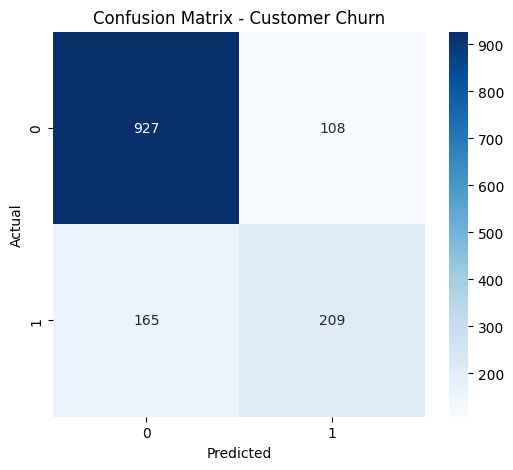

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Customer Churn")

plt.show()

In [128]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
precision = precision_score(y_test, predictions)

print("Precision:", precision)
recall = recall_score(y_test, predictions)

print("Recall:", recall)
f1 = f1_score(y_test, predictions)

print("F1 Score:", f1)

Accuracy: 0.8062455642299503
Precision: 0.6593059936908517
Recall: 0.5588235294117647
F1 Score: 0.6049204052098408
ROC AUC Score: 0.8421710713270816


In [129]:
churn_probabilities = model.predict_proba(X_test)[:, 1]

In [130]:
auc = roc_auc_score(
    y_test,
    churn_probabilities
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8421710713270816


In [131]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



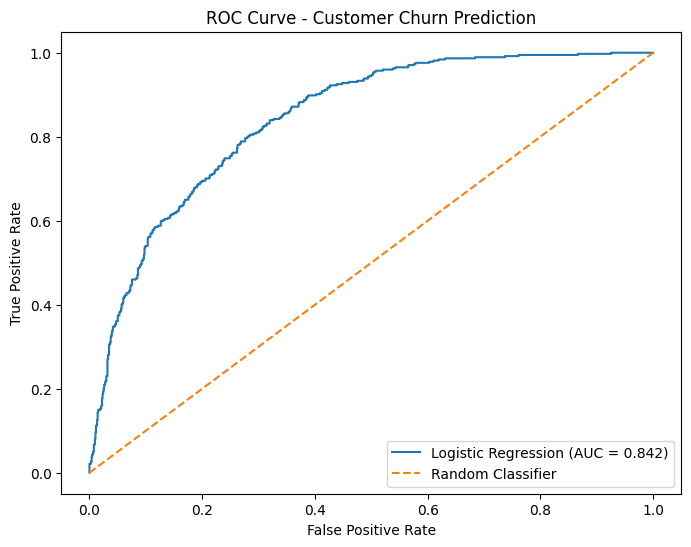

In [132]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    churn_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()

plt.show()

In [133]:
threshold = 0.4

predictions_04 = (
    churn_probabilities >= threshold
).astype(int)

In [134]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, predictions_04))
print("Recall   :", recall_score(y_test, predictions_04))
print("F1 Score :", f1_score(y_test, predictions_04))

Precision: 0.5697940503432495
Recall   : 0.6657754010695187
F1 Score : 0.6140567200986436


In [135]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    preds = (churn_probabilities >= threshold).astype(int)

    precisions.append(
        precision_score(y_test, preds, zero_division=0)
    )

    recalls.append(
        recall_score(y_test, preds, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_test, preds, zero_division=0)
    )

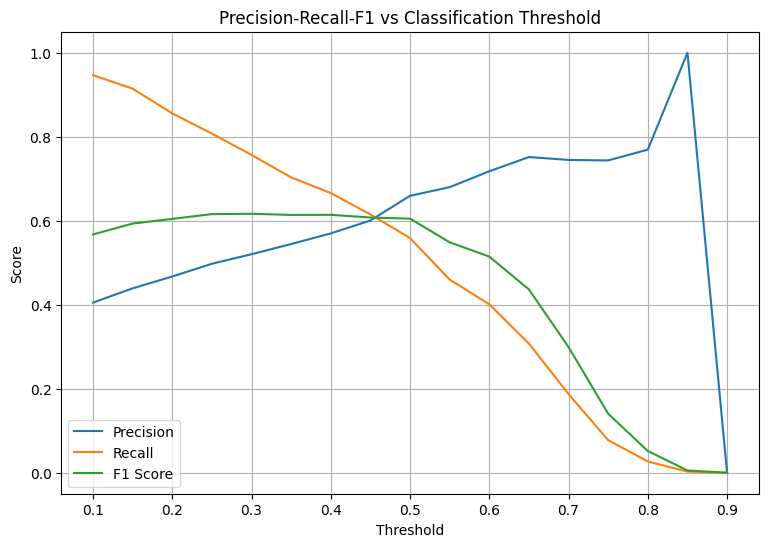

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Classification Threshold")
plt.legend()
plt.grid()

plt.show()

In [137]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best threshold: 0.30000000000000004
Best F1 Score: 0.616557734204793


In [138]:
best_predictions = (
    churn_probabilities >= best_threshold
).astype(int)

print("Precision:",
      precision_score(y_test, best_predictions))

print("Recall:",
      recall_score(y_test, best_predictions))

print("F1 Score:",
      f1_score(y_test, best_predictions))

Precision: 0.5202205882352942
Recall: 0.7566844919786097
F1 Score: 0.616557734204793
